# Coding Project 1: Linear Regression and Regularization

**Please write the names of all group members here:**




---

*Note:* The provided structure for the code below is only suggestive. You may structure your program differently, provided that your notebook is readable, reproducible, and answers all questions clearly.

A minimal `sklearn` workflow example is included before Question 3. It is intended to illustrate the use of `ColumnTransformer`, `Pipeline`, and `GridSearchCV`; it does **not** solve the project questions for you.

### Question 1 - Importing and Preparing the Data

C:\Users\karim\AppData\Local\Temp\ipykernel_31688\2905404629.py:78: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


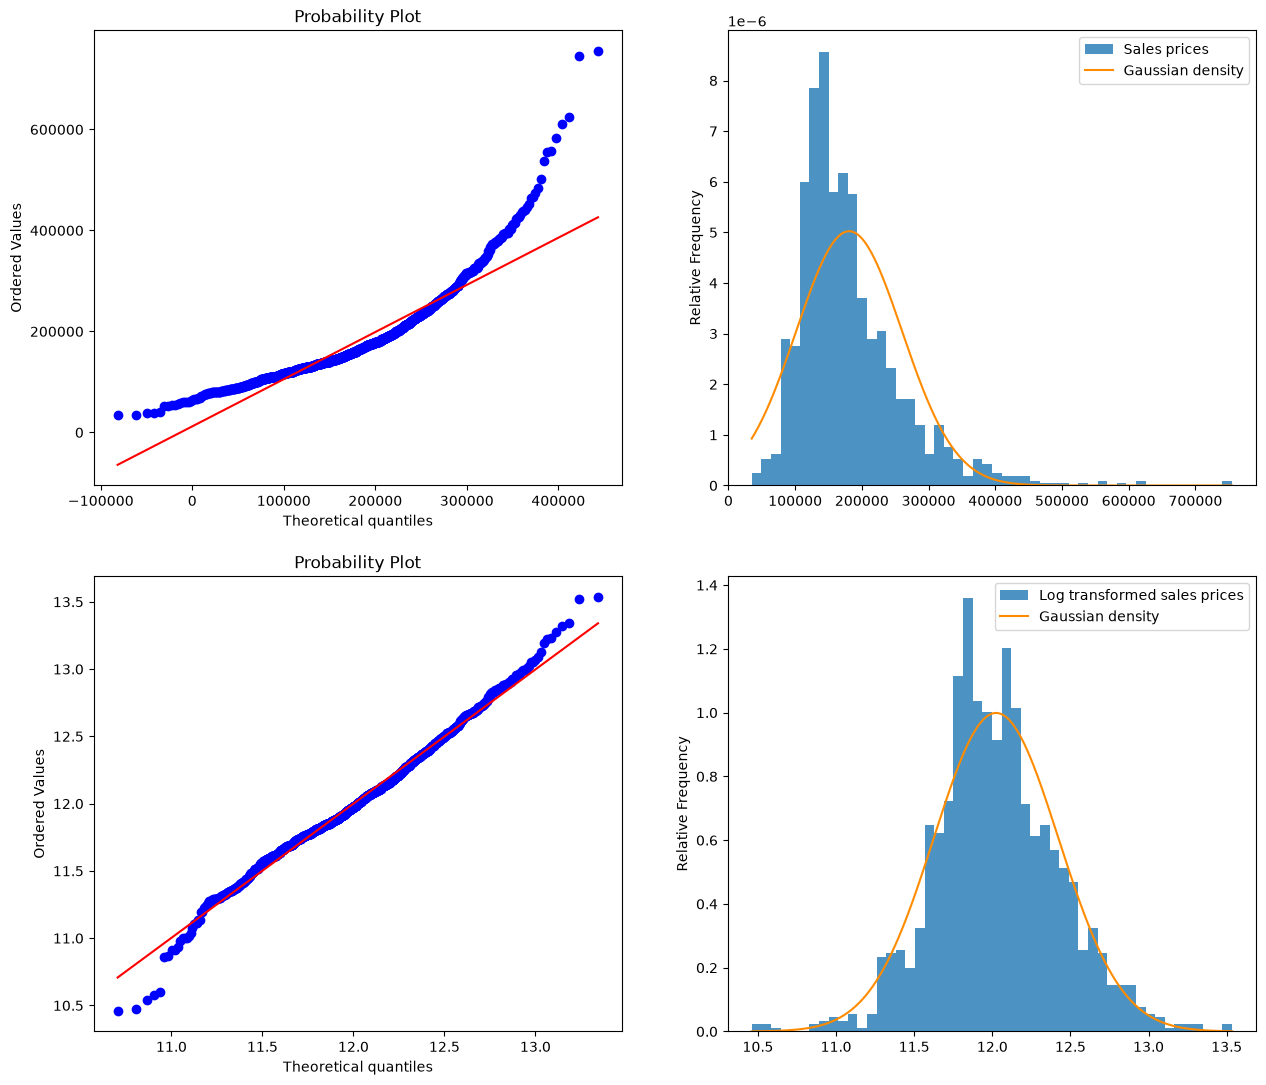

In [32]:
# For Question 1, you may find the following packages useful:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.model_selection import train_test_split

# 1.a) Import Housing.csv as a pandas DataFrame.
# Separate the explanatory features X from the target y = SalePrice.
#
# Guidance:
# - Refer to data_description.txt to determine how variables should be interpreted.
# - The first column of the csv file is an index and should not be used as an explanatory variable.
# - Keep the original variable names so that later coefficient tables are easy to interpret.
ds = pd.read_csv("./data/Housing.csv", index_col="Id")
y = ds["SalePrice"]
X = ds.drop(columns="SalePrice", inplace=False)

categorical_cols = pd.Index(["MSSubClass","MSZoning","Street","Alley","LotShape","LandContour","Utilities","LotConfig","LandSlope","Neighborhood","Condition1","Condition2","BldgType","HouseStyle","RoofStyle","RoofMatl","Exterior1st","Exterior2nd","MasVnrType","ExterQual","ExterCond","Foundation","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","Heating","HeatingQC","CentralAir","Electrical","KitchenQual","Functional","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PavedDrive","PoolQC","Fence","MiscFeature","SaleType","SaleCondition"])
categorical_NA_allowed = pd.Index(["Alley","BsmtQual","BsmtCond","BsmtExposure","BsmtFinType1","BsmtFinType2","FireplaceQu","GarageType","GarageFinish","GarageQual","GarageCond","PoolQC","Fence","MiscFeature"])
categorical_NA_not_allowed = categorical_cols.difference(categorical_NA_allowed)

numerical_cols = X.columns.difference(categorical_cols)


# 1.b) Graphically determine whether SalePrice is approximately Gaussian.
# If it is not, suggest and apply a suitable transformation.
# Explain why considering such a transformation can be important.
#
# Guidance:
# - Use suitable graphical diagnostics (for example, a histogram and/or Q-Q plot).
# - Keep track of the transformation you choose because later questions require metrics
#   both on the transformed scale and, after inverse transformation, on the original
#   SalePrice scale.
np.random.seed(67)

# Important variables relating to SalePrice directly
mean = np.average(y)
sd = np.std(y)
var = np.power(sd, 2)
support = (np.min(y), np.max(y))
x_axis = np.linspace(support[0], support[1], num=500)
normal_y = 1/np.sqrt(2*np.pi*var) * np.exp(-(1/(2*var)*np.power(x_axis - mean, 2)))

# Important variables relating to logarithm of SalePrice
y_log = np.log(y)
mean_log = np.average(y_log)
sd_log = np.std(y_log)
var_log = np.power(sd_log, 2)
support_log = (np.min(y_log), np.max(y_log))
x_axis_log = np.linspace(support_log[0], support_log[1], num=500)
normal_y_log = 1/np.sqrt(2*np.pi*var_log) * np.exp(-(1/(2*var_log)*np.power(x_axis_log - mean_log, 2)))

# Setting up the suplots
fig, ((qqax1, histax1),(qqax2, histax2)) = plt.subplots(2,2)
fig.set_size_inches(15,13)

# Plotting histograms of sales prices and log transformed sales prices against a fitted gaussian density
saleprice_hist = histax1.hist(y, bins=50, density=True, alpha=.8, label="Sales prices")
normal_density = histax1.plot(x_axis, normal_y, color="darkorange", label="Gaussian density")

saleprice_hist_log = histax2.hist(y_log, bins=50, density=True, alpha=.8, label="Log transformed sales prices")
normal_density_log = histax2.plot(x_axis_log, normal_y_log, color="darkorange", label="Gaussian density")

# Plotting the QQPlots of sales prices and log transformed sales prices
stats.probplot(y, dist=stats.norm(loc=mean, scale=sd), fit=True, plot=qqax1)
stats.probplot(y_log, dist=stats.norm(loc=mean_log, scale=sd_log), fit=True, plot=qqax2)

# Labels
histax1.set_ylabel("Relative Frequency")
histax1.legend(loc="upper right")

histax2.set_ylabel("Relative Frequency")
histax2.legend(loc="upper right")

# Savefig and show
fig.savefig("./plots/QQplots_Histograms_y_log-y.png")
fig.show()

# 1.c) Split the data into training and test sets.
# Randomly assign 70% of the observations to the training set and 30% to the test set.
#
# IMPORTANT:
# - Save an UNPROCESSED copy of X_train and X_test before doing any imputation,
#   standardization, or one-hot encoding.
# - You will return to these raw splits in Question 3.b) to build a leakage-safe
#   cross-validation pipeline.
#
# Suggested naming:
# X_train_raw, X_test_raw, y_train, y_test

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3)

# 1.d) Prepare X_train and X_test using TRAINING-SET information only.
#
# Required steps:
# (i)   Numerical missing values: impute with the corresponding training-set mean.
# (ii)  Categorical missing values: impute with the most frequent category in the
#       corresponding training column.
# (iii) Treat 'NA' / 'None' as actual categorical levels where the data description
#       specifies that they are valid categories, rather than automatically treating
#       them as missing.
# (iv)  Standardize numerical features using training-set means and standard deviations,
#       and apply the same transformation, using these training-set statistics, to
#       the test set.
# (v)   One-hot encode the categorical variables.
# (vi)  Ensure that the test set contains the same encoded feature columns, in the
#       same order, as the training set.
#
# Hint:
# If pd.get_dummies is applied separately to the training and test sets, they may
# produce different dummy-variable columns because some categorical levels occur
# in only one of the two sets. The regression model must receive the same feature
# columns at training and prediction time. One possible way to align the encoded
# test columns to the training columns is:
#
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
#
# This creates any training dummy column missing from the test set and fills it
# with zero, while also matching the training-column order.
#
# Expected output / checks:
# - Report the final shapes of the prepared training and test feature matrices.
# - Verify that the encoded feature columns and their order are identical.
# - Do not use any test-set statistic to fit the preprocessing.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create copies of X_train and X_test
X_train = X_train_raw.copy(deep=True)
X_test = X_test_raw.copy(deep=True)


# Impute numerical features
num_imputer = SimpleImputer(strategy="mean")
X_train[numerical_cols] = num_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = num_imputer.transform(X_test[numerical_cols])

# Standardize numerical features
std_scaler = StandardScaler()
X_train[numerical_cols] = std_scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = std_scaler.transform(X_test[numerical_cols])

# Impute categorical features (missing value/most frequent imputation)
cat_missing_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_NA_not_allowed] = cat_missing_imputer.fit_transform(X_train[categorical_NA_not_allowed])
X_test[categorical_NA_not_allowed] = cat_missing_imputer.transform(X_test[categorical_NA_not_allowed])

# Impute categorical features (value not missing/constant imputation)
cat_const_imputer = SimpleImputer(strategy="constant", fill_value="NA")
X_train[categorical_NA_allowed] = cat_const_imputer.fit_transform(X_train[categorical_NA_allowed])
X_test[categorical_NA_allowed] = cat_const_imputer.transform(X_test[categorical_NA_allowed])

# One-hot encode categorical features
cat_onehot_encoder = OneHotEncoder(categories='auto', handle_unknown='infrequent_if_exist', sparse_output=False).set_output(transform="pandas")
X_train_encoded = cat_onehot_encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = cat_onehot_encoder.transform(X_test[categorical_cols])

X_train_encoded[numerical_cols] = X_train[numerical_cols]
X_test_encoded[numerical_cols] = X_test[numerical_cols]

X_train_encoded.to_csv("./data/Housing_X_train.csv")
X_test_encoded.to_csv("./data/Housing_X_test.csv")

In [33]:
X_train_encoded.info()
X_test_encoded.info()

<class 'pandas.DataFrame'>
Index: 1022 entries, 1202 to 836
Columns: 308 entries, MSSubClass_20 to YrSold
dtypes: float64(308)
memory usage: 2.4 MB
<class 'pandas.DataFrame'>
Index: 438 entries, 1339 to 701
Columns: 308 entries, MSSubClass_20 to YrSold
dtypes: float64(308)
memory usage: 1.0 MB


### Question 2 - Linear Regression on Numerical Features

In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
from tabulate import tabulate, SEPARATING_LINE

# 2.a) Fit an OLS regression using ONLY the numerical predictors and sklearn.
# Include an intercept.
#
# Required output:
# - A table with each numerical feature and its estimated regression coefficient.
# - In-sample and out-of-sample MSE and R^2.
# - If y was transformed in Question 1.b), report MSE and R^2:
#     * on the transformed target scale; and
#     * on the original SalePrice scale after inverse-transforming predictions.
# - Briefly explain what the two scales tell you about model performance.
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

numerical_ols = LinearRegression(fit_intercept=True)
numerical_ols.fit(X_train_encoded[numerical_cols], y_train_log)

numerical_ols_coefs = numerical_ols.coef_
feature_coef_arr = np.array([numerical_cols, numerical_ols_coefs]).T
feature_coef_arr = np.insert(feature_coef_arr, 0, ["(intercept)", numerical_ols.intercept_], axis=0)

y_train_pred = numerical_ols.predict(X_train_encoded[numerical_cols])
y_pred = numerical_ols.predict(X_test_encoded[numerical_cols])

y_train_pred_transformed = np.exp(y_train_pred)
y_pred_transformed = np.exp(y_pred)

model_evaluation = [
    ["Log-scale in-sample MSE", mean_squared_error(y_train_log, y_train_pred)],
    ["Log-scale out-of-sample MSE", mean_squared_error(y_test_log, y_pred)],
    ["SalePrice scale in-sample MSE", mean_squared_error(y_train, y_train_pred_transformed)],
    ["SalePrice scale out-of-sample MSE", mean_squared_error(y_test, y_pred_transformed)],
    SEPARATING_LINE,
    ["Log-scale in-sample R^2 score", r2_score(y_train_log, y_train_pred)],
    ["Log-scale out-of-sample R^2 score", r2_score(y_test_log, y_pred)],
    ["SalePrice scale in-sample R^2 score", r2_score(y_train, y_train_pred_transformed)],
    ["SalePrice scale out-of-sample R^2 score", r2_score(y_test, y_pred_transformed)]
]

print(tabulate(model_evaluation, ["Evaluation method", "Evaluation"], tablefmt="outline"))
print("The Log-scale metrics are easier to compare, while the SalePrice scale allows for more intuitive interpretation.")

# 2.b) Reproduce and investigate OLS using matrix algebra on the TRAINING SET ONLY.
#
# Let A denote the design matrix containing the numerical predictors plus a column
# of ones for the intercept.
#
# (i) Compute the estimated coefficients using numpy.
#     Use a numerically stable linear-system solver such as np.linalg.solve(...)
#     whenever the system is numerically well behaved; do not explicitly form
#     a matrix inverse merely to solve the normal equations.
#
#     Expected output:
#     - Estimated intercept and feature coefficients.
#     - A comparison with the sklearn estimates from Question 2.a).

X_train_matrix = X_train_encoded[numerical_cols].to_numpy()
X_train_matrix = np.insert(X_train_matrix, 0, np.ones(y_train.shape), axis=1)

beta_hat = np.linalg.solve(X_train_matrix.T @ X_train_matrix, X_train_matrix.T @ y_train_log)
feature_coef_arr = np.insert(feature_coef_arr, 2, beta_hat, axis=1)

# (ii) Compute the standard error of each estimated coefficient using numpy.
#
#      Expected output:
#      - A table containing coefficient estimates and their standard errors,
#        including the intercept.
#      - Clearly state which estimate corresponds to the intercept.

y_hat = X_train_matrix @ beta_hat
y_hat_transformed = np.exp(y_hat)
(m, d) = X_train_matrix.shape

sample_std = np.sum(np.pow(y_train_log - y_hat, 2))/(m-(d+1))
covariance_matrix = np.linalg.inv(X_train_matrix.T @ X_train_matrix)
se_vector = np.array([sample_std * covariance_matrix[j,j] for j in range(d)])

feature_coef_arr = np.insert(feature_coef_arr, 3, se_vector, axis=1)

print(tabulate(feature_coef_arr, ["Feature Name", "sklearn Coefficients", "Normal Equation Coefficients", "SE(beta_hat_j)"], tablefmt="outline"))

+-----------------------------------------+--------------+
| Evaluation method                       |   Evaluation |
+=========================================+==============+
| Log-scale in-sample MSE                 |  0.0239656   |
| Log-scale out-of-sample MSE             |  0.0177366   |
| SalePrice scale in-sample MSE           |  1.59629e+09 |
| SalePrice scale out-of-sample MSE       |  5.82708e+08 |
+=========================================+==============+
| Log-scale in-sample R^2 score           |  0.859093    |
| Log-scale out-of-sample R^2 score       |  0.868159    |
| SalePrice scale in-sample R^2 score     |  0.771196    |
| SalePrice scale out-of-sample R^2 score |  0.876549    |
+-----------------------------------------+--------------+
The Log-scale metrics are easier to compare, while the SalePrice scale allows for more intuitive interpretation.
+----------------+------------------------+--------------------------------+------------------+
| Feature Name   |   skl

In [35]:
# (iii) Using your matrix-algebra implementation, verify that the in-sample
#       MSE and R^2 agree with the corresponding results from Question 2.a),
#       up to numerical rounding.
metric_comparison = [
    ["sklearn log-transformed", mean_squared_error(y_train_log, y_train_pred), r2_score(y_train_log, y_train_pred)],
    ["matrix log-transformed", mean_squared_error(y_train_log, y_hat), r2_score(y_train_log, y_hat)],
    SEPARATING_LINE,
    ["sklearn SalePrice scale", mean_squared_error(y_train, y_train_pred_transformed), r2_score(y_train, y_train_pred_transformed)],
    ["matrix SalePrice scale", mean_squared_error(y_train, y_hat_transformed), r2_score(y_train, y_hat_transformed)],
]

print(tabulate(metric_comparison, ["MSE", "R^2 score"], tablefmt="outline"))

+-------------------------+--------------+----------------+
|                         |          MSE |      R^2 score |
+=========================+==============+================+
| sklearn log-transformed |  0.0239656   |    0.859093    |
| matrix log-transformed  | 18.4158      | -107.277       |
+=========================+==============+================+
| sklearn SalePrice scale |  1.59629e+09 |    0.771196    |
| matrix SalePrice scale  |  3.00446e+25 |   -4.30644e+15 |
+-------------------------+--------------+----------------+


In [36]:
# (iv) Inspect the numerical structure of A.
#
#      Required diagnostics:
#      - rank of A;
#      - singular values of A.
#
#      Guidance:
#      - np.linalg.matrix_rank(...) and np.linalg.svd(..., compute_uv=False)
#        may be useful.
#      - Comment on whether A is full column rank.
#      - Inspect the smallest singular values and discuss whether they suggest
#        potential numerical instability.
#      - Relate this evidence to the OLS calculations above.

print(f'Rank of A: {np.linalg.matrix_rank(X_train_matrix)}/{d}')
print(f'Singular values of A: {np.linalg.svd(X_train_matrix, compute_uv=False)}')
print(f'The squared singular values of A are the eigenvalues of A^TA. The fact that the smallest singular value is close to 0 makes it so the entries in the inverse of A^TA blow up.')


Rank of A: 34/36
Singular values of A: [8.66917274e+01 5.60336163e+01 5.12675014e+01 4.40625506e+01
 3.75291781e+01 3.49003264e+01 3.46292845e+01 3.45124181e+01
 3.36913713e+01 3.33383855e+01 3.28353768e+01 3.20217851e+01
 3.19687347e+01 3.13430236e+01 3.08681909e+01 3.00045498e+01
 2.91476385e+01 2.88937507e+01 2.81944259e+01 2.70870322e+01
 2.63627634e+01 2.52656367e+01 2.50747108e+01 2.42692025e+01
 2.33265661e+01 1.98019250e+01 1.80296813e+01 1.69121134e+01
 1.56585287e+01 1.51149328e+01 1.39790357e+01 1.19020979e+01
 1.10931842e+01 9.86225089e+00 9.51157502e-15 6.52605554e-15]
The squared singular values of A are the eigenvalues of A^TA. The fact that the smallest singular value is close to 0 makes it so the entries in the inverse of A^TA blow up.


In [37]:
# (v) Replace the usual inverse-based expression by the Moore-Penrose pseudoinverse.
#     Use np.linalg.pinv(...) with its default cutoff.
#
#     Required comparison:
#     - Do the coefficient estimates change?
#     - Does the residual variance estimate change?
#     - Do the standard errors change?
#     - Explain when the ordinary inverse-based and pseudoinverse-based results
#       should agree and when they may differ, using the diagnostics from (iv).

beta_hat_pinv = np.linalg.pinv(X_train_matrix) @ y_train_log
feature_coef_arr = np.insert(feature_coef_arr, 4, beta_hat_pinv, axis=1)

y_hat_pinv = X_train_matrix @ beta_hat_pinv
y_hat_pinv_transformed = np.exp(y_hat_pinv)
(m, d) = X_train_matrix.shape

sample_std_pinv = np.sum(np.pow(y_train_log - y_hat_pinv, 2))/(m-(d+1))
covariance_matrix = np.linalg.inv(X_train_matrix.T @ X_train_matrix)
se_vector = np.array([sample_std_pinv * covariance_matrix[j,j] for j in range(d)])

feature_coef_arr = np.insert(feature_coef_arr, 5, se_vector, axis=1)

print(f'Normal Equation residual variance: {sample_std}')
print(f'Moore-Penrose residual variance: {sample_std_pinv}')
print(tabulate(feature_coef_arr, ["Feature Name", "sklearn Coefficients", "Normal Equation Coefficients", "SE(beta_hat_j)", "Moore-Pensore Coefficients", "SE(beta_hat_pinv_j)"], tablefmt="outline"))

Normal Equation residual variance: 19.107571538663922
Moore-Penrose residual variance: 0.024865880618040646
+----------------+------------------------+--------------------------------+------------------+------------------------------+-----------------------+
| Feature Name   |   sklearn Coefficients |   Normal Equation Coefficients |   SE(beta_hat_j) |   Moore-Pensore Coefficients |   SE(beta_hat_pinv_j) |
+================+========================+================================+==================+==============================+=======================+
| (intercept)    |           12.028       |                   10.9718      |      0.0105043   |                 12.028       |           1.36699e-05 |
| 1stFlrSF       |            0.0397187   |                    9.21694e+13 |     -5.94103e+25 |                  0.0397187   |          -7.73144e+22 |
| 2ndFlrSF       |            0.0143119   |                    9.99988e+13 |     -6.99323e+25 |                  0.0143119   |          -

In [38]:
# (vi) Confirm your results with statsmodels OLS.
#
#      Required output:
#      - Coefficient estimates and standard errors from statsmodels.
#      - Compare them with your matrix-algebra results up to numerical rounding.
#      - If they differ, relate the discrepancy to the rank / numerical-stability
#        diagnostics above.

sm_ols_model = sm.OLS(y_train_log, sm.add_constant(X_train_encoded[numerical_cols]), hasconst="add")
sm_ols_fit = sm_ols_model.fit()

feature_coef_arr = np.insert(feature_coef_arr, 6, np.array(sm_ols_fit.params), axis=1)
feature_coef_arr = np.insert(feature_coef_arr, 7, np.array(sm_ols_fit.bse), axis=1)

print(tabulate(feature_coef_arr, ["Feature Name", "sklearn Coefficients", "Normal Equation Coefficients", "SE(beta_hat_j)", "Moore-Pensore Coefficients", "SE(beta_hat_pinv_j)", "statsmodels Coefficients", "SE(beta_hat_j)"], tablefmt="outline"))

+----------------+------------------------+--------------------------------+------------------+------------------------------+-----------------------+----------------------------+------------------+
| Feature Name   |   sklearn Coefficients |   Normal Equation Coefficients |   SE(beta_hat_j) |   Moore-Pensore Coefficients |   SE(beta_hat_pinv_j) |   statsmodels Coefficients |   SE(beta_hat_j) |
+================+========================+================================+==================+==============================+=======================+============================+==================+
| (intercept)    |           12.028       |                   10.9718      |      0.0105043   |                 12.028       |           1.36699e-05 |               12.028       |       0.00492511 |
| 1stFlrSF       |            0.0397187   |                    9.21694e+13 |     -5.94103e+25 |                  0.0397187   |          -7.73144e+22 |                0.0397187   |       0.00815661 |
| 2nd

C:\Users\karim\AppData\Local\Temp\ipykernel_31688\3823089129.py:10: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  sm_ols_fit = sm_ols_model.fit()


### Minimal sklearn Workflow Example (Illustration Only)

In [39]:
# This example demonstrates the WORKFLOW required in Question 3.b):
#
# raw data
#   -> ColumnTransformer
#   -> Pipeline
#   -> GridSearchCV
#   -> best hyperparameters / CV score
#   -> refitted best estimator
#   -> held-out test evaluation
#
# It uses a small artificial dataset and Ridge regression. It is NOT a solution
# to the housing problem, and its hyperparameter grid should not be copied blindly.

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold, train_test_split
from sklearn.metrics import mean_squared_error

# ----- 1. Create a tiny mixed-type example dataset -----
rng = np.random.default_rng(1)
n = 60

X_example = pd.DataFrame({
    "size": rng.normal(100, 15, n),
    "age": rng.normal(20, 7, n),
    "region": rng.choice(["A", "B", "C"], size=n),
})

# Add a few missing values only to illustrate preprocessing.
X_example.loc[[2, 11, 31], "size"] = np.nan
X_example.loc[[5, 27], "region"] = np.nan

# Construct an arbitrary regression target.
region_effect = X_example["region"].map({"A": 0.0, "B": 5.0, "C": -3.0}).fillna(0.0)
y_example = (
    2.0 * X_example["size"].fillna(X_example["size"].mean())
    - 1.5 * X_example["age"]
    + region_effect
    + rng.normal(0, 5, n)
)

X_ex_train, X_ex_test, y_ex_train, y_ex_test = train_test_split(
    X_example, y_example, test_size=0.25, random_state=1
)

# ----- 2. Define preprocessing -----
numeric_features = ["size", "age"]
categorical_features = ["region"]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_example = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

# ----- 3. Put preprocessing and the model in ONE pipeline -----
pipeline_example = Pipeline([
    ("preprocessor", preprocessor_example),
    ("model", Ridge()),
])

# Pipeline parameter names use step__parameter.
param_grid_example = {
    "model__alpha": [0.1, 1.0, 10.0],
}

# Define the CV folds once. The same idea can be used to ensure fair model comparisons.
cv_example = KFold(n_splits=4, shuffle=True, random_state=1)

search_example = GridSearchCV(
    estimator=pipeline_example,
    param_grid=param_grid_example,
    scoring="neg_mean_squared_error",
    cv=cv_example,
    refit=True,
)

# IMPORTANT:
# During each CV split, the preprocessing steps are fitted only on that fold's
# training observations because they are inside the Pipeline.
search_example.fit(X_ex_train, y_ex_train)

# ----- 4. Inspect the selected configuration and its CV performance -----
best_idx = search_example.best_index_
cv_mean_mse = -search_example.cv_results_["mean_test_score"][best_idx]
cv_std_mse = search_example.cv_results_["std_test_score"][best_idx]

print("Best parameters:", search_example.best_params_)
print(f"Mean CV MSE: {cv_mean_mse:.3f}")
print(f"Std. CV MSE: {cv_std_mse:.3f}")

# ----- 5. Final held-out test evaluation -----
# With refit=True (the default), best_estimator_ has already been refitted on ALL
# of X_ex_train using the selected hyperparameters.
best_model_example = search_example.best_estimator_
test_pred_example = best_model_example.predict(X_ex_test)
test_mse_example = mean_squared_error(y_ex_test, test_pred_example)

print(f"Test MSE: {test_mse_example:.3f}")

# Things to understand before Question 3.b):
# - Why must the preprocessing be inside the Pipeline during CV?
# - Why is the parameter called "model__alpha"?
# - What does refit=True do after CV selects the best hyperparameters?
# - Why should the held-out test set be used only after model selection?

# Visualize the structure of the pipeline
pipeline_example


Best parameters: {'model__alpha': 0.1}
Mean CV MSE: 26.085
Std. CV MSE: 12.683
Test MSE: 41.051


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### Question 3 - Regularization Techniques

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import GridSearchCV, KFold

# 3.a) Fit OLS using ALL prepared explanatory variables (numerical + categorical).
#
# Use the prepared Housing dataset from Question 1.d).
#
# Required output:
# - In-sample and out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
# - If the target was transformed, inverse-transform predictions before computing
#   these metrics.
# - Compare the results with the regression using only numerical features from
#   Question 2.a).
# - Does including the categorical features improve out-of-sample predictive
#   performance?
# - How does the gap between in-sample and out-of-sample performance change?



# 3.b) Implement and tune:
# - Truncated Pseudoinverse regression;
# - Ridge;
# - Lasso;
# - Elastic Net.
#
# Use 8-fold CV, MSE as the model-selection criterion, and the SAME CV folds
# for all four methods.
#
# IMPORTANT: Start from the UNPROCESSED X_train_raw / X_test_raw saved in 1.c).
# The preprocessing must be INSIDE the Pipeline so that all learned preprocessing
# quantities are estimated separately within each CV training fold.
#
# Follow the workflow below.


# 3.b.i) Build ONE reusable preprocessing component.
#
# It should reproduce the rules from Question 1.d):
# - numerical imputation;
# - numerical standardization;
# - categorical imputation;
# - one-hot encoding;
# - correct treatment of 'NA' / 'None' where these are valid categorical levels.
#
# Make sure a category that is absent from a particular CV training fold does not
# cause an error when its validation fold is transformed.
#
# Hint: OneHotEncoder has an option for handling categories not seen during fit.



# 3.b.ii) Construct one Pipeline for each method using the SAME preprocessor.
#
# Required structures:
#
# Ridge / Lasso / Elastic Net:
# raw data -> preprocessor -> model
#
# Truncated Pseudoinverse:
# raw data -> preprocessor -> TruncatedSVD -> LinearRegression
#
# All regressions should contain an intercept, and the intercept should NOT be
# regularized.
#
# Do not implement a custom TPI estimator: use TruncatedSVD as the dimensionality-
# reduction step before LinearRegression.



# 3.b.iii) Define reasonable hyperparameter grids and tune with GridSearchCV.
#
# Tune:
# - regularization strength for Ridge;
# - regularization strength for Lasso;
# - regularization strength and mixing parameter for Elastic Net;
# - number of retained singular directions for Truncated Pseudoinverse.
#   With sklearn's TruncatedSVD, this is n_components: the number of retained
#   singular components, not a singular-value cutoff.
#
# Pipeline parameters follow the step__parameter convention.
# Examples of the NAMING convention (not recommended parameter values):
# - model__alpha
# - model__l1_ratio
# - svd__n_components
#
# Define ONE 8-fold CV splitter and reuse it for every method so the comparison
# uses exactly the same folds.
#
# Use MSE as the selection criterion. sklearn commonly expresses this as
# scoring="neg_mean_squared_error" because GridSearchCV maximizes scores.



# 3.b.iv) Inspect the selected hyperparameters.
#
# For EACH method:
# - Check whether the selected value lies at or near a boundary of the grid.
# - If it does, extend the relevant range and repeat the search.
# - Briefly justify the final grid / range you report.
#
# Do not stop automatically at the first grid if the optimum appears constrained
# by the range you chose.



# 3.b.v) Evaluate the selected and refitted models.
#
# With refit=True, GridSearchCV refits the selected pipeline on the COMPLETE outer
# training set after cross-validation.
#
# Required final metrics:
# - in-sample MSE and R^2 on the ORIGINAL SalePrice scale;
# - out-of-sample MSE and R^2 on the ORIGINAL SalePrice scale.
#
# If y was transformed, inverse-transform predictions before computing these
# final train/test metrics.
#
# Compare the four regularized methods with BOTH OLS benchmarks from 2.a) and 3.a).



# 3.b) REQUIRED SUMMARY TABLE
#
# Include the four regularized models and the OLS benchmarks from 2.a) and 3.a).
# For quantities that do not apply to OLS, use "--".
#
# Suggested columns:
# Model
# Selected hyperparameter(s)
# Mean CV MSE
# Std. CV MSE
# In-sample MSE
# In-sample R^2
# Out-of-sample MSE
# Out-of-sample R^2
#
# For each regularized model, the CV MSE is the mean validation MSE across the
# 8 folds for the SELECTED hyperparameter configuration.
#
# Hint:
# - search.best_index_ identifies the selected row in search.cv_results_.
# - search.cv_results_["mean_test_score"][search.best_index_] gives the selected
#   mean CV score.
# - search.cv_results_["std_test_score"][search.best_index_] gives its standard
#   deviation across validation folds.
# - If scoring="neg_mean_squared_error", reverse the sign of mean_test_score when
#   reporting MSE. Do NOT reverse the sign of the standard deviation.
#
# If SalePrice was transformed, the CV MSE used for model selection is on the
# transformed target scale. The final in-sample / out-of-sample metrics above
# should be reported on the original SalePrice scale.



# Why is it important that the intercept is not penalized during regularization?



# 3.c) Pipeline parameter notation and refitting.
#
# Explain:
# - What a pipeline parameter name such as model__alpha means.
# - What refit=True in GridSearchCV does after the best hyperparameters have
#   been selected.
# - Why this refitting step is useful before the final evaluation on the
#   held-out test set.



# 3.d) Sparsity versus singular-direction truncation.
#
# Required output / discussion:
# - Number of non-zero FEATURE coefficients for Lasso (exclude the intercept).
# - Number of non-zero FEATURE coefficients for Elastic Net (exclude the intercept).
# - Compare with Ridge, which generally shrinks coefficients without setting them
#   exactly to zero.
# - For Truncated Pseudoinverse, report the SELECTED NUMBER OF SINGULAR DIRECTIONS,
#   rather than counting non-zero regression coefficients.
# - Explain why truncating singular directions is conceptually different from
#   coefficient sparsity in Lasso / Elastic Net.



# 3.e) Final model recommendation.
#
# Which model would you recommend for predicting house prices?
#
# Support the recommendation using BOTH:
# - empirical performance; and
# - the structure of the problem.
#
# Relevant considerations may include:
# - number of features;
# - categorical variables / one-hot encoding;
# - collinearity;
# - sparsity;
# - interpretability;
# - stability / robustness;
# - nonlinearity and other limitations of linear models.
#
# Explain how the strengths and limitations of your selected method align with
# the problem structure.


### Project Report

At the end of the notebook, provide a concise synthesis of your analysis. Do not simply repeat every answer above.

#### Approach
Briefly summarize the preprocessing and modeling workflow.

#### Model selection
Explain how the models and hyperparameters were selected, including the cross-validation procedure.

#### Key results
Summarize the most important quantitative results.

#### Interpretation
Explain what the results imply about the regression methods and the housing problem.

#### Robustness
Discuss relevant checks such as leakage prevention, numerical stability, and hyperparameter-grid adequacy.

#### Limitations
State the main limitations of the analysis and models.